In [ ]:
import tensorflow as tf

print(tf.__version__)
a=tf.random.uniform([2,3],0,1)
print(a)
print(type(a))

2.19.0
tf.Tensor(
[[0.27468956 0.39546037 0.1225121 ]
 [0.7470132  0.6301923  0.2090981 ]], shape=(2, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [ ]:
import tensorflow as tf
import numpy as np

t = tf.random.uniform([2, 3], 0, 1)  # 2행 3열 형태의 텐서를 0 이상 1 미만의 균등분포에서 무작위로 생성함의 수행
n = np.random.uniform(0, 1, [2, 3])  # 2행 3열 형태의 ndarray를 0 이상 1 미만의 균등분포에서 무작위로 생성함의 수행

print("tensorflow로 생성한 텐서:\n", t, "\n")  # 텐서 t의 출력 수행
print(type(t))                                # 객체 t의 자료형 확인 수행

print("numpy로 생성한 ndarray:\n", n, "\n")  # 배열 n의 출력 수행
print(type(n))                               # 객체 n의 자료형 확인 수행

res = t + n  # 텐서 t와 ndarray n의 원소별 덧셈 연산 수행
print("덧셈 결과:\n", res)  # 연산 결과 res의 출력 수행
print(type(res))           # 결과 객체 res의 자료형 확인 수행

# TensorFlow와 NumPy 간의 연산이 가능한 이유
    # TensorFlow가 NumPy 객체를 자동으로 Tensor로 변환함
    # NumPy 연산과 호환되도록 설계된 TensorFlow 연산 시스템



tensorflow로 생성한 텐서:
 tf.Tensor(
[[0.9289051  0.05414236 0.17922759]
 [0.49006116 0.7837758  0.91267323]], shape=(2, 3), dtype=float32) 

<class 'tensorflow.python.framework.ops.EagerTensor'>
numpy로 생성한 ndarray:
 [[0.84476668 0.35732214 0.88504317]
 [0.17132044 0.68406422 0.51400863]] 

<class 'numpy.ndarray'>
덧셈 결과:
 tf.Tensor(
[[1.7736719  0.41146448 1.0642707 ]
 [0.6613816  1.46784    1.4266819 ]], shape=(2, 3), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [ ]:
import tensorflow as tf
import tensorflow.keras.datasets as ds

# MNIST 읽고 텐서 모양 출력
(x_train, y_train), (x_test, y_test) = ds.mnist.load_data()  # MNIST 데이터셋의 학습 및 테스트셋 로딩 수행
yy_train = tf.one_hot(y_train, 10, dtype=tf.int8)  # 다중 클래스 라벨을 원-핫 인코딩 방식으로 변환 수행
print("MNIST: ", x_train.shape, y_train.shape, yy_train.shape)  # 학습 데이터와 라벨, 원핫 라벨의 형태 출력 수행

# CIFAR-10 읽고 텐서 모양 출력
(x_train, y_train), (x_test, y_test) = ds.cifar10.load_data()  # CIFAR-10 데이터셋의 학습 및 테스트셋 로딩 수행
yy_train = tf.one_hot(y_train, 10, dtype=tf.int8)  # 라벨을 원-핫 인코딩 방식으로 변환 수행
print("CIFAR-10: ", x_train.shape, y_train.shape, yy_train.shape)  # 데이터와 라벨, 원핫 라벨의 형태 출력 수행

# Boston Housing 읽고 텐서 모양 출력
(x_train, y_train), (x_test, y_test) = ds.boston_housing.load_data()  # Boston Housing 데이터셋 로딩 수행
print("Boston Housing: ", x_train.shape, y_train.shape)  # 입력 특성과 타깃 벡터의 형태 출력 수행

# Reuters 읽고 텐서 모양 출력
(x_train, y_train), (x_test, y_test) = ds.reuters.load_data()  # Reuters 뉴스 텍스트 분류 데이터셋 로딩 수행
print("Reuters: ", x_train.shape, y_train.shape)  # 뉴스 기사 시퀀스와 라벨의 형태 출력 수행


MNIST:  (60000, 28, 28) (60000,) (60000, 10)
CIFAR-10:  (50000, 32, 32, 3) (50000, 1) (50000, 1, 10)
Boston Housing:  (404, 13) (404,)
Reuters:  (8982,) (8982,)


In [ ]:
import tensorflow as tf

# OR 데이터 구축
x = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]  # 입력 벡터 집합 정의 수행
y = [[-1], [1], [1], [1]]                             # 정답 라벨(OR 논리 결과) 정의 수행 (-1: False, 1: True)

# [그림 4-3(b)]의 퍼셉트론
w = tf.Variable([[1.0], [1.0]])  # 가중치 벡터 초기화 수행
b = tf.Variable(-0.5)            # 편향(bias) 값 초기화 수행

# 식 4.3의 퍼셉트론 동작
s = tf.add(tf.matmul(x, w), b)  # 입력과 가중치의 행렬곱 결과에 편향 더하기 연산 수행
o = tf.sign(s)                  # 퍼셉트론 활성화 함수로 부호 함수(sign 함수) 적용 수행

print(o)        # 퍼셉트론 출력 결과 출력 수행
print(y == o)   # 예측 결과와 정답 비교 결과 출력 수행 (Boolean 형태로 일치 여부 확인)


# ------------------------

# 동작 설명 요약

# 입력 x는 OR 연산의 가능한 4개 경우를 포함
# 출력 y는 각각의 OR 결과를 -1(False), 1(True)로 표현
# 퍼셉트론은 선형결합 s = x @ w + b를 수행한 후, **부호 함수(sign)**를 통해 최종 출력을 만듬
# tf.sign() 함수는 다음과 같이 작동합:
#     양수 → 1
#     0 → 0
#     음수 → -1

# ------------------------

# 이 코드에서 확인할 수 있는 것

# 지정된 가중치 w=[[1],[1]]와 편향 b=-0.5는 OR 문제를 완벽하게 분류할 수 있습니다.
# 출력 o는 [-1, 1, 1, 1]이며, 이는 y와 정확히 일치합니다.
# print(y == o) 결과는 [True, True, True, True]가 됩니다.



tf.Tensor(
[[-1.]
 [ 1.]
 [ 1.]
 [ 1.]], shape=(4, 1), dtype=float32)
tf.Tensor(
[[ True]
 [ True]
 [ True]
 [ True]], shape=(4, 1), dtype=bool)


In [11]:
import tensorflow as tf

# -----------------------------------------
# TensorFlow를 사용해 단층 신경망(퍼셉트론)으로 OR 논리를 학습하는 예제

# sigmoid 활성화 함수와 이진 크로스 엔트로피 손실 함수를 사용하며, 옵티마이저는 SGD
# -----------------------------------------

# OR 데이터
x = tf.constant([[0,0],[0,1],[1,0],[1,1]], dtype=tf.float32)  # 입력 벡터 정의 수행
y = tf.constant([[0],[1],[1],[1]], dtype=tf.float32)          # 정답 벡터 정의 수행

# 가중치와 편향 초기화
w = tf.Variable(tf.random.normal([2,1]))  # 가중치 w를 평균 0, 표준편차 1의 정규분포에서 초기화 수행
b = tf.Variable(tf.random.normal([1]))    # 편향 b를 정규분포에서 초기화 수행

# 손실 함수 정의
def loss():
    logits = tf.matmul(x, w) + b  # 입력과 가중치의 행렬곱과 편향의 덧셈 수행
    return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=logits))  # 평균 이진 크로스 엔트로피 손실 계산 수행

# 옵티마이저 정의
opt = tf.keras.optimizers.SGD(learning_rate=0.1)  # 학습률 0.1을 가지는 SGD 옵티마이저 정의 수행

# 학습 반복
for i in range(500):  # 총 500번 반복 수행
    with tf.GradientTape() as tape:  # 자동 미분을 위한 그래디언트 테이프 생성 수행
        current_loss = loss()  # 현재 손실 값 계산 수행
    grads = tape.gradient(current_loss, [w, b])  # 손실에 대한 가중치와 편향의 기울기 계산 수행
    opt.apply_gradients(zip(grads, [w, b]))  # 계산된 그래디언트를 이용한 파라미터 갱신 수행

    if i % 100 == 0:
        print('loss at epoch', i, '=', current_loss.numpy())  # 100 에폭마다 손실 값 출력 수행


# 예측
logits = tf.matmul(x, w) + b  # 학습된 가중치와 편향을 이용한 선형결합 수행
preds = tf.sigmoid(logits)    # sigmoid 함수를 통해 확률로 변환 수행
print("예측 결과:\n", preds.numpy())  # 예측 결과 출력 수행



loss at epoch 0 = 1.1948242
loss at epoch 100 = 0.22923696
loss at epoch 200 = 0.18547916
loss at epoch 300 = 0.15856108
loss at epoch 400 = 0.13829339
예측 결과:
 [[0.24928935]
 [0.89752233]
 [0.9128421 ]
 [0.9963929 ]]


In [ ]:
# Keras를 활용하여 OR 게이트를 퍼셉트론으로 학습하는 예제이며, 활성화 함수로 tanh를 사용

# ---------------------------------------

# 전체 흐름 요약

# 입력(x), 출력(y) 정의
# Keras Sequential 모델 정의
# Dense 층(출력 1, tanh 활성화) 추가
# 컴파일 후 MSE 손실로 학습
# 예측 결과 출력

# ---------------------------------------

from tensorflow.keras.models import Sequential  # 순차적 모델 정의 클래스 임포트 수행
from tensorflow.keras.layers import Dense      # 완전연결(Dense) 층 임포트 수행
# Keras의 Dense는 완전 연결 계층(Fully Connected Layer) 또는 전결합층이라고도 불리는 층
from tensorflow.keras.optimizers import SGD    # 확률적 경사하강법(SGD) 옵티마이저 임포트 수행
import numpy as np                             # 넘파이 라이브러리 임포트 수행

# OR 데이터 구축
x = [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]]  # 입력 벡터 정의 수행
y = [[-1], [1], [1], [1]]                             # 정답 라벨 정의 수행 (-1: False, 1: True 형태로 표현)

# Convert x and y to numpy arrays
x = np.array(x)  # 입력 리스트를 넘파이 배열로 변환 수행
y = np.array(y)  # 출력 리스트를 넘파이 배열로 변환 수행

n_input = 2    # 입력 차원 수 정의 수행
n_output = 1   # 출력 차원 수 정의 수행

perceptron = Sequential()  # 순차적 모델 생성 수행

# Dense 층 추가: 출력 유닛 수 1개, tanh 활성화, 가중치 초기화는 균등분포, 편향은 0
perceptron.add(Dense(units=n_output, activation='tanh', input_shape=(n_input,),
                     kernel_initializer='random_uniform', bias_initializer='zeros'))

# 모델 컴파일: 손실 함수는 평균 제곱 오차(mse), 옵티마이저는 SGD
perceptron.compile(loss='mse', optimizer=SGD(learning_rate=0.1), metrics=['mse'])

# 모델 학습: 에폭 수 500, 학습 과정 출력은 간략히(verbose=2)
perceptron.fit(x, y, epochs=500, verbose=2)

res = perceptron.predict(x)  # 학습된 모델로 입력 x에 대한 예측 수행
print(res)                   # 예측 결과 출력 수행

Epoch 1/500


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 - 0s - 215ms/step - loss: 0.9932 - mse: 0.9932
Epoch 2/500
1/1 - 0s - 19ms/step - loss: 0.7464 - mse: 0.7464
Epoch 3/500
1/1 - 0s - 20ms/step - loss: 0.6383 - mse: 0.6383
Epoch 4/500
1/1 - 0s - 25ms/step - loss: 0.5852 - mse: 0.5852
Epoch 5/500
1/1 - 0s - 41ms/step - loss: 0.5530 - mse: 0.5530
Epoch 6/500
1/1 - 0s - 19ms/step - loss: 0.5298 - mse: 0.5298
Epoch 7/500
1/1 - 0s - 19ms/step - loss: 0.5112 - mse: 0.5112
Epoch 8/500
1/1 - 0s - 19ms/step - loss: 0.4949 - mse: 0.4949
Epoch 9/500
1/1 - 0s - 21ms/step - loss: 0.4802 - mse: 0.4802
Epoch 10/500
1/1 - 0s - 20ms/step - loss: 0.4665 - mse: 0.4665
Epoch 11/500
1/1 - 0s - 20ms/step - loss: 0.4535 - mse: 0.4535
Epoch 12/500
1/1 - 0s - 20ms/step - loss: 0.4410 - mse: 0.4410
Epoch 13/500
1/1 - 0s - 19ms/step - loss: 0.4290 - mse: 0.4290
Epoch 14/500
1/1 - 0s - 19ms/step - loss: 0.4175 - mse: 0.4175
Epoch 15/500
1/1 - 0s - 30ms/step - loss: 0.4064 - mse: 0.4064
Epoch 16/500
1/1 - 0s - 19ms/step - loss: 0.3956 - mse: 0.3956
Epoch 17/500

Epoch 1/30


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


469/469 - 3s - 6ms/step - accuracy: 0.8429 - loss: 0.0429 - val_accuracy: 0.9086 - val_loss: 0.0307
Epoch 2/30
469/469 - 3s - 6ms/step - accuracy: 0.9281 - loss: 0.0227 - val_accuracy: 0.9433 - val_loss: 0.0180
Epoch 3/30
469/469 - 3s - 6ms/step - accuracy: 0.9468 - loss: 0.0164 - val_accuracy: 0.9529 - val_loss: 0.0151
Epoch 4/30
469/469 - 3s - 5ms/step - accuracy: 0.9571 - loss: 0.0137 - val_accuracy: 0.9579 - val_loss: 0.0132
Epoch 5/30
469/469 - 3s - 6ms/step - accuracy: 0.9631 - loss: 0.0120 - val_accuracy: 0.9617 - val_loss: 0.0118
Epoch 6/30
469/469 - 3s - 6ms/step - accuracy: 0.9677 - loss: 0.0108 - val_accuracy: 0.9650 - val_loss: 0.0107
Epoch 7/30
469/469 - 3s - 6ms/step - accuracy: 0.9716 - loss: 0.0101 - val_accuracy: 0.9666 - val_loss: 0.0102
Epoch 8/30
469/469 - 3s - 6ms/step - accuracy: 0.9735 - loss: 0.0094 - val_accuracy: 0.9664 - val_loss: 0.0103
Epoch 9/30
469/469 - 3s - 5ms/step - accuracy: 0.9761 - loss: 0.0088 - val_accuracy: 0.9699 - val_loss: 0.0097
Epoch 10/30


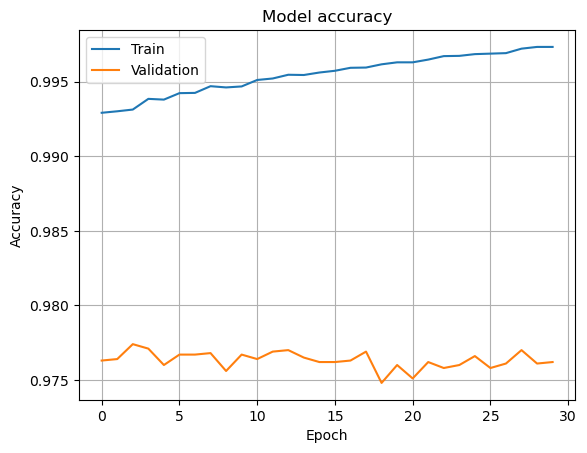

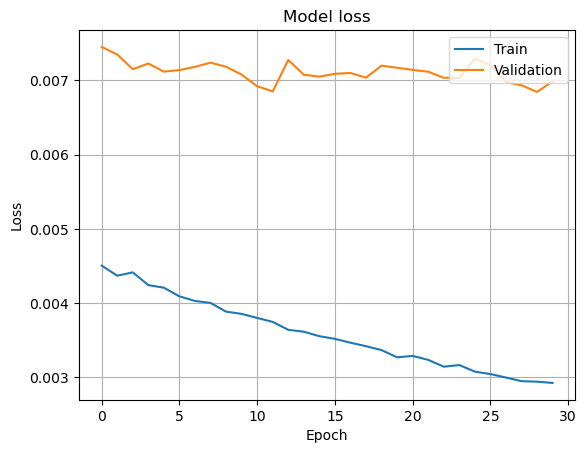

In [17]:
# 다층 퍼셉트론(MLP)**을 이용하여 MNIST 숫자 분류 문제를 학습하는 전형적인 예제
# TensorFlow의 Keras API를 사용하며, 학습 진행 후 정확도 및 손실 그래프를 시각화

# --------------------------------------

# 전체 구조 개요

# MNIST 데이터 로딩 및 전처리
# MLP 모델 구성 및 컴파일
# 모델 학습
# 평가 및 시각화

# --------------------------------------


import numpy as np                        # 넘파이 라이브러리 임포트 수행
import tensorflow as tf                   # 텐서플로우 임포트 수행
from tensorflow.keras.datasets import mnist  # MNIST 데이터셋 로딩 모듈 임포트 수행

from tensorflow.keras.models import Sequential     # 순차적 모델 클래스 임포트 수행
from tensorflow.keras.layers import Dense          # 완전 연결 층 클래스 임포트 수행
from tensorflow.keras.optimizers import Adam       # Adam 옵티마이저 임포트 수행

(x_train, y_train), (x_test, y_test) = mnist.load_data()  # MNIST 훈련/테스트 데이터 로딩 수행

x_train = x_train.reshape(60000, 784)  # 28x28 이미지를 1차원 벡터로 변환 수행
x_test = x_test.reshape(10000, 784)

x_train = x_train.astype(np.float32) / 255.0  # 픽셀 값을 0~1 범위로 정규화 수행
x_test = x_test.astype(np.float32) / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)  # 라벨을 원-핫 인코딩 수행
y_test = tf.keras.utils.to_categorical(y_test, 10)

n_input = 784      # 입력 노드 수 정의 수행
n_hidden = 1024    # 은닉층 노드 수 정의 수행
n_output = 10      # 출력 노드 수 정의 수행 (0~9)

mlp = Sequential()  # 순차적 모델 생성 수행

# 은닉층: tanh 활성화, 가중치 균등분포 초기화, 편향 0 초기화 수행
mlp.add(Dense(units=n_hidden, activation='tanh', input_shape=(n_input,),
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# 출력층: tanh 활성화, 출력 10개
mlp.add(Dense(units=n_output, activation='tanh',
              kernel_initializer='random_uniform', bias_initializer='zeros'))

# 손실 함수: MSE, 옵티마이저: Adam
mlp.compile(loss='mean_squared_error', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# 모델 학습: 배치 크기 128, 에폭 수 30, 검증 데이터 포함
hist = mlp.fit(x_train, y_train, batch_size=128, epochs=30,
               validation_data=(x_test, y_test), verbose=2)

# 모델 학습: 배치 크기 128, 에폭 수 30, 검증 데이터 포함
hist = mlp.fit(x_train, y_train, batch_size=128, epochs=30,
               validation_data=(x_test, y_test), verbose=2)

import matplotlib.pyplot as plt  # 시각화 라이브러리 임포트 수행

# 정확률 곡선
plt.plot(hist.history['accuracy'])         # 훈련 정확도 시각화 수행
plt.plot(hist.history['val_accuracy'])     # 검증 정확도 시각화 수행
plt.title('Model accuracy')                # 제목 설정 수행
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')  # 범례 설정 수행
plt.grid()
plt.show()

# 손실 함수 곡선
plt.plot(hist.history['loss'])             # 훈련 손실 시각화 수행
plt.plot(hist.history['val_loss'])         # 검증 손실 시각화 수행
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid()
plt.show()



Epoch 1/30
469/469 - 3s - 6ms/step - accuracy: 0.8164 - loss: 0.5158 - val_accuracy: 0.8305 - val_loss: 0.4764
Epoch 2/30
469/469 - 3s - 6ms/step - accuracy: 0.8529 - loss: 0.4038 - val_accuracy: 0.8360 - val_loss: 0.4330
Epoch 3/30
469/469 - 3s - 5ms/step - accuracy: 0.8689 - loss: 0.3608 - val_accuracy: 0.8631 - val_loss: 0.3890
Epoch 4/30
469/469 - 3s - 5ms/step - accuracy: 0.8756 - loss: 0.3383 - val_accuracy: 0.8635 - val_loss: 0.3870
Epoch 5/30
469/469 - 3s - 6ms/step - accuracy: 0.8845 - loss: 0.3153 - val_accuracy: 0.8676 - val_loss: 0.3734
Epoch 6/30
469/469 - 3s - 6ms/step - accuracy: 0.8869 - loss: 0.3041 - val_accuracy: 0.8627 - val_loss: 0.3830
Epoch 7/30
469/469 - 3s - 5ms/step - accuracy: 0.8928 - loss: 0.2849 - val_accuracy: 0.8711 - val_loss: 0.3537
Epoch 8/30
469/469 - 2s - 5ms/step - accuracy: 0.8990 - loss: 0.2724 - val_accuracy: 0.8729 - val_loss: 0.3483
Epoch 9/30
469/469 - 3s - 5ms/step - accuracy: 0.9028 - loss: 0.2601 - val_accuracy: 0.8819 - val_loss: 0.3328
E

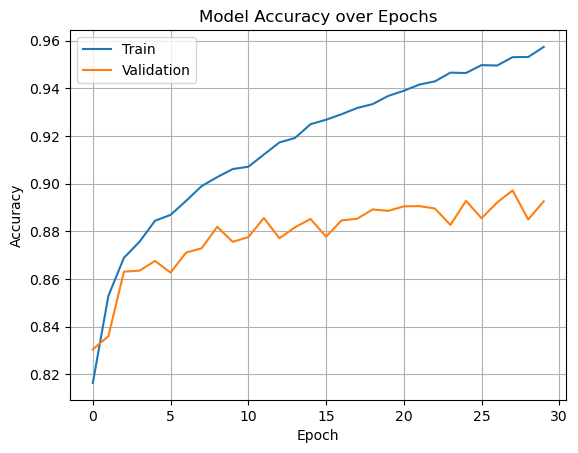

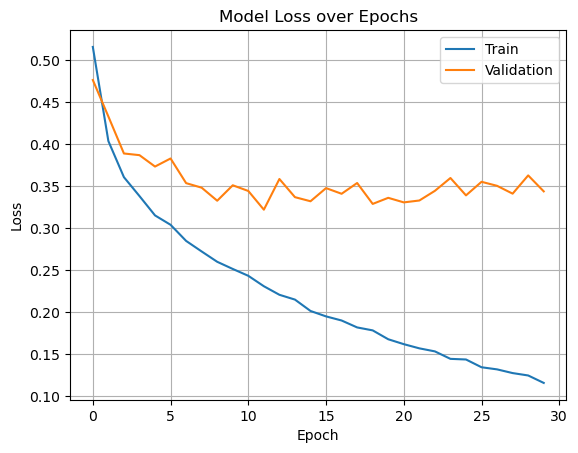

In [18]:
# 좀 전의 MNIST 코드는 교육 목적의 단순 퍼셉트론 구현 예제에 가까웠고,
# Fashion MNIST 코드는 실제 분류 문제에 적합하게 개선된 코드

# 만약 MNIST 코드에도 동일한 개선(softmax, categorical_crossentropy)을 적용하면 완전히 같은 구조로 사용할 수 있음

## ---------------------------------------------------------------
# [Fashion MNIST 다층 퍼셉트론(MLP) 분류기 구현]
# 1. Fashion MNIST 의류 이미지 데이터셋 로딩 및 전처리 수행
# 2. 입력층(784), 은닉층(1024, tanh), 출력층(10, softmax)으로 MLP 구성
# 3. 손실 함수는 categorical_crossentropy, 옵티마이저는 Adam 적용
# 4. 학습 및 검증 정확도/손실 변화를 시각화하여 모델 성능 확인
# ---------------------------------------------------------------

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. Fashion MNIST 데이터셋 로딩
#    - 10종류의 의류 이미지 (28x28 픽셀, 흑백)
#    - 학습용 60,000장 / 테스트용 10,000장으로 구성
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. 입력 데이터 전처리
#    - 이미지 데이터를 (28x28) → (784,) 형태의 벡터로 변환하여 Dense 층에 입력 가능하도록 처리
#    - 각 픽셀 값을 0~255 → 0~1 범위로 정규화하여 학습 안정성 향상
x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0

# 3. 라벨 데이터를 원-핫 인코딩으로 변환
#    - 정수형 클래스(예: 3 → 셔츠)를 벡터형 라벨([0, 0, 0, 1, 0, ...])로 변환
#    - 다중 클래스 분류에서 softmax 출력과 crossentropy 손실에 필수적인 전처리
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 4. 모델 파라미터 정의
#    - 입력 벡터 크기: 28x28 = 784
#    - 은닉층 뉴런 수: 1024개 (모델의 표현력 증가 목적)
#    - 출력 클래스 수: 10개 (의류 종류 10종)
n_input = 784
n_hidden = 1024
n_output = 10

# 5. MLP 모델 구성
mlp = Sequential()

# [은닉층]
#    - 뉴런 수: 1024
#    - 활성화 함수: tanh (비선형성 확보)
#    - 가중치 초기화: 균등분포(random_uniform), 편향은 0으로 초기화
#    - 입력 데이터 형태: (784,)
mlp.add(Dense(units=n_hidden, activation='tanh',
              input_shape=(n_input,),
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

# [출력층]
#    - 뉴런 수: 10 (클래스 수와 동일)
#    - 활성화 함수: softmax (클래스별 확률 출력)
#    - 가중치/편향 초기화 동일
mlp.add(Dense(units=n_output, activation='softmax',
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

# 6. 모델 컴파일
#    - 손실 함수: categorical_crossentropy (원-핫 라벨 + softmax 출력에 최적)
#    - 옵티마이저: Adam (적응적 학습률 조절 기능 포함)
#    - 평가 지표: 정확도(accuracy)
mlp.compile(loss='categorical_crossentropy',
            optimizer=Adam(learning_rate=0.001),
            metrics=['accuracy'])

# 7. 모델 학습
#    - 배치 크기: 128개 샘플씩 한 번에 학습
#    - 총 학습 반복 횟수: 30 에폭
#    - 검증용 데이터로 테스트셋 사용하여 과적합 여부 관찰
#    - verbose=2 설정으로 에폭별 요약 정보 출력
hist = mlp.fit(x_train, y_train,
               batch_size=128,
               epochs=30,
               validation_data=(x_test, y_test),
               verbose=2)

# 8. 테스트셋 평가 및 정확도 출력
#    - 모델이 본 적 없는 데이터에 대해 일반화 성능 확인
res = mlp.evaluate(x_test, y_test, verbose=0)
print("정확률은", res[1] * 100)

# 9. 학습 및 검증 정확도 시각화
#    - 에폭별 정확도 변화를 통해 학습 효과 및 과적합 여부 확인
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid()
plt.show()

# 10. 학습 및 검증 손실 시각화
#     - 손실 값이 낮을수록 예측과 실제 정답 간의 오차가 적음을 의미
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid()
plt.show()


Epoch 1/30
469/469 - 6s - 12ms/step - accuracy: 0.8964 - loss: 0.0260 - val_accuracy: 0.9441 - val_loss: 0.0127
Epoch 2/30
469/469 - 5s - 11ms/step - accuracy: 0.9551 - loss: 0.0098 - val_accuracy: 0.9554 - val_loss: 0.0085
Epoch 3/30
469/469 - 5s - 11ms/step - accuracy: 0.9688 - loss: 0.0066 - val_accuracy: 0.9693 - val_loss: 0.0060
Epoch 4/30
469/469 - 5s - 11ms/step - accuracy: 0.9751 - loss: 0.0052 - val_accuracy: 0.9740 - val_loss: 0.0051
Epoch 5/30
469/469 - 5s - 11ms/step - accuracy: 0.9804 - loss: 0.0041 - val_accuracy: 0.9746 - val_loss: 0.0049
Epoch 6/30
469/469 - 5s - 11ms/step - accuracy: 0.9833 - loss: 0.0036 - val_accuracy: 0.9758 - val_loss: 0.0049
Epoch 7/30
469/469 - 5s - 11ms/step - accuracy: 0.9855 - loss: 0.0031 - val_accuracy: 0.9769 - val_loss: 0.0043
Epoch 8/30
469/469 - 5s - 10ms/step - accuracy: 0.9867 - loss: 0.0029 - val_accuracy: 0.9789 - val_loss: 0.0042
Epoch 9/30
469/469 - 5s - 11ms/step - accuracy: 0.9889 - loss: 0.0026 - val_accuracy: 0.9778 - val_loss:

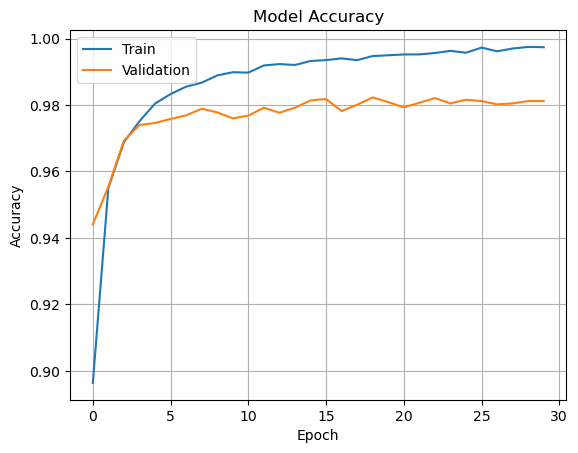

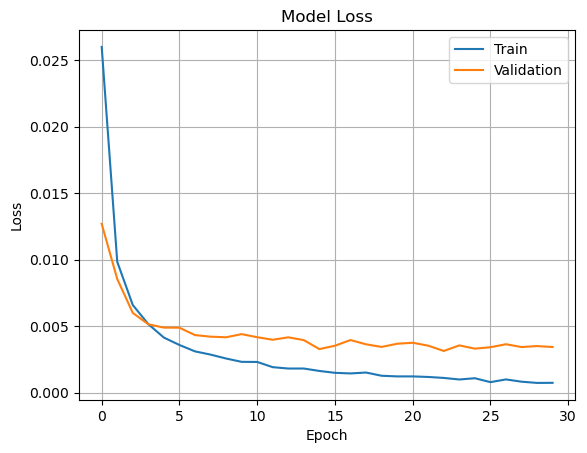

In [19]:
# ---------------------------------------------------------------
# [MNIST 숫자 분류기 - 심층 다층 퍼셉트론(MLP)]
# 1. MNIST 손글씨 이미지 데이터셋 로딩 및 전처리
# 2. 총 4개의 은닉층과 1개의 출력층으로 구성된 MLP 모델 설계
#    - 은닉층: tanh 활성화 함수, 뉴런 수: 1024, 512, 512, 512
#    - 출력층: tanh 활성화 함수, 뉴런 수: 10
# 3. 손실 함수: mean_squared_error (← softmax + crossentropy 추천됨)
# 4. 학습 정확도 및 손실 시각화
# ---------------------------------------------------------------

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. MNIST 데이터셋 로딩
#    - 0~9 숫자 이미지 (28x28 흑백)
#    - 학습: 60,000개, 테스트: 10,000개
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. 입력 데이터 전처리
#    - 2D 이미지(28x28)를 1D 벡터(784)로 변환
#    - 픽셀 값을 0~255 → 0~1 범위로 정규화
x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0

# 3. 라벨 데이터 전처리
#    - 정수 라벨(0~9)을 원-핫 벡터로 변환 (예: 2 → [0,0,1,0,0,0,0,0,0,0])
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 4. 신경망 구조 정의
#    - 입력층 크기: 784 (28x28 이미지)
#    - 은닉층: 1024 → 512 → 512 → 512 (총 4층)
#    - 출력층: 10 클래스 (softmax 대신 tanh 사용됨)
n_input = 784
n_hidden1 = 1024
n_hidden2 = 512
n_hidden3 = 512
n_hidden4 = 512
n_output = 10

# 5. 신경망 모델 구성
mlp = Sequential()

# 첫 번째 은닉층: 입력 받는 첫 층
mlp.add(Dense(units=n_hidden1, activation='tanh',
              input_shape=(n_input,),
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

# 두 번째 ~ 네 번째 은닉층
mlp.add(Dense(units=n_hidden2, activation='tanh',
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

mlp.add(Dense(units=n_hidden3, activation='tanh',
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

mlp.add(Dense(units=n_hidden4, activation='tanh',
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

# 출력층: 10개의 클래스 출력, 현재는 tanh 활성화 사용 (softmax 추천)
mlp.add(Dense(units=n_output, activation='tanh',
              kernel_initializer='random_uniform',
              bias_initializer='zeros'))

# 6. 모델 컴파일
#    - 손실 함수: mean_squared_error (원-핫 라벨에 사용 가능하나 분류 문제에는 비권장)
#    - 옵티마이저: Adam (적응적 학습률)
#    - 평가지표: 정확도
mlp.compile(loss='mean_squared_error',
            optimizer=Adam(learning_rate=0.001),
            metrics=['accuracy'])

# 7. 모델 학습
#    - 배치 사이즈: 128
#    - 총 에폭 수: 30
#    - 검증 데이터로 테스트셋 사용
hist = mlp.fit(x_train, y_train,
               batch_size=128,
               epochs=30,
               validation_data=(x_test, y_test),
               verbose=2)

# 8. 테스트셋을 이용한 최종 정확률 평가
res = mlp.evaluate(x_test, y_test, verbose=0)
print("정확률은", res[1] * 100)

# 9. 학습 과정 시각화: 정확도 변화
plt.plot(hist.history['accuracy'])         # 학습 정확도
plt.plot(hist.history['val_accuracy'])     # 검증 정확도
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid()
plt.show()

# 10. 학습 과정 시각화: 손실 변화
plt.plot(hist.history['loss'])             # 학습 손실
plt.plot(hist.history['val_loss'])         # 검증 손실
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.grid()
plt.show()


Epoch 1/30
469/469 - 6s - 12ms/step - accuracy: 0.8939 - loss: 0.0163 - val_accuracy: 0.9361 - val_loss: 0.0101
Epoch 2/30
469/469 - 5s - 11ms/step - accuracy: 0.9367 - loss: 0.0097 - val_accuracy: 0.9461 - val_loss: 0.0082
Epoch 3/30
469/469 - 5s - 10ms/step - accuracy: 0.9520 - loss: 0.0075 - val_accuracy: 0.9563 - val_loss: 0.0069
Epoch 4/30
469/469 - 5s - 10ms/step - accuracy: 0.9627 - loss: 0.0059 - val_accuracy: 0.9611 - val_loss: 0.0059
Epoch 5/30
469/469 - 5s - 10ms/step - accuracy: 0.9683 - loss: 0.0050 - val_accuracy: 0.9607 - val_loss: 0.0061
Epoch 6/30
469/469 - 5s - 10ms/step - accuracy: 0.9735 - loss: 0.0043 - val_accuracy: 0.9696 - val_loss: 0.0047
Epoch 7/30
469/469 - 5s - 10ms/step - accuracy: 0.9775 - loss: 0.0037 - val_accuracy: 0.9702 - val_loss: 0.0044
Epoch 8/30
469/469 - 5s - 10ms/step - accuracy: 0.9806 - loss: 0.0032 - val_accuracy: 0.9723 - val_loss: 0.0042
Epoch 9/30
469/469 - 5s - 10ms/step - accuracy: 0.9835 - loss: 0.0028 - val_accuracy: 0.9751 - val_loss:

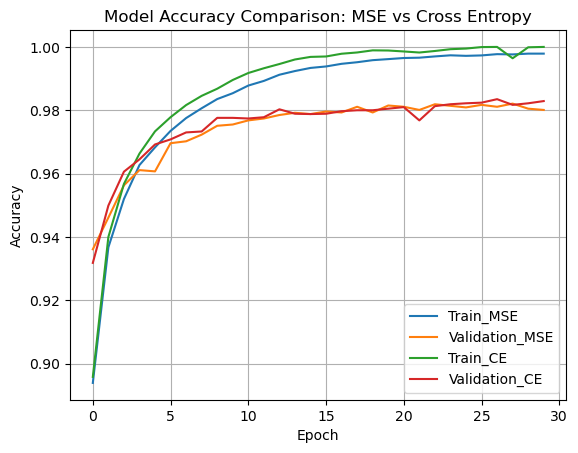

In [20]:
# ---------------------------------------------------------------
# [MSE vs Cross Entropy 손실 함수 비교 실험 - MNIST 분류 문제]
# 목적:
#   동일한 다층 퍼셉트론(MLP) 모델 구조에서 손실 함수만 다르게 설정하여,
#   분류 문제에서 '평균제곱오차(MSE)'와 '범주형 교차 엔트로피(categorical_crossentropy)'가
#   실제 학습 성능에 어떤 영향을 미치는지를 비교 분석함
# ---------------------------------------------------------------

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 1. MNIST 손글씨 숫자 데이터셋 로딩
#    - 학습용: 60,000개, 테스트용: 10,000개 이미지
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. 입력 이미지 전처리
#    - 28x28 크기의 2D 이미지 → 784 차원의 1D 벡터로 변환
#    - 정수형 픽셀 값(0~255)을 실수형으로 변환 후 0~1 범위로 정규화
x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0

# 3. 라벨(정답) 전처리
#    - 0~9 정수 라벨을 원-핫 인코딩 벡터로 변환 (예: 3 → [0,0,0,1,0,0,0,0,0,0])
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 4. 신경망 구조 정의 (MLP)
#    - 입력층(784) → 은닉층 4개 → 출력층(10 클래스)
n_input = 784
n_hidden1 = 1024
n_hidden2 = 512
n_hidden3 = 512
n_hidden4 = 512
n_output = 10

# ---------------------------- MSE 모델 ----------------------------

# 5. 평균제곱오차(MSE)를 사용하는 모델 정의
dmlp_mse = Sequential()

# 입력층 + 은닉층 1: 1024개 뉴런, tanh 활성화 함수 사용
dmlp_mse.add(Dense(units=n_hidden1, activation='tanh', input_shape=(n_input,)))

# 은닉층 2~4: 512개 뉴런, tanh 활성화 함수 사용
dmlp_mse.add(Dense(units=n_hidden2, activation='tanh'))
dmlp_mse.add(Dense(units=n_hidden3, activation='tanh'))
dmlp_mse.add(Dense(units=n_hidden4, activation='tanh'))

# 출력층: 10개 뉴런, softmax 활성화 함수로 클래스 확률 출력
dmlp_mse.add(Dense(units=n_output, activation='softmax'))

# 모델 컴파일
#    - 손실 함수: mean_squared_error → 분류 문제에 권장되지 않음 (회귀용 손실 함수)
#    - 옵티마이저: Adam, 학습률 0.0001
#    - 평가 지표: 정확도
dmlp_mse.compile(loss='mean_squared_error',
                 optimizer=Adam(learning_rate=0.0001),
                 metrics=['accuracy'])

# 모델 학습 실행
#    - 배치 크기: 128, 에폭: 30, 검증 데이터: 테스트셋
hist_mse = dmlp_mse.fit(x_train, y_train,
                        batch_size=128,
                        epochs=30,
                        validation_data=(x_test, y_test),
                        verbose=2)

# ------------------------- Cross Entropy 모델 -------------------------

# 6. 범주형 교차 엔트로피(categorical_crossentropy)를 사용하는 모델 정의
dmlp_ce = Sequential()

# 입력층 + 은닉층 1~4 (구조 동일)
dmlp_ce.add(Dense(units=n_hidden1, activation='tanh', input_shape=(n_input,)))
dmlp_ce.add(Dense(units=n_hidden2, activation='tanh'))
dmlp_ce.add(Dense(units=n_hidden3, activation='tanh'))
dmlp_ce.add(Dense(units=n_hidden4, activation='tanh'))

# 출력층: softmax 활성화 사용
dmlp_ce.add(Dense(units=n_output, activation='softmax'))

# 모델 컴파일
#    - 손실 함수: categorical_crossentropy → 다중 클래스 분류 문제에 가장 널리 사용
dmlp_ce.compile(loss='categorical_crossentropy',
                optimizer=Adam(learning_rate=0.0001),
                metrics=['accuracy'])

# 모델 학습 실행
hist_ce = dmlp_ce.fit(x_train, y_train,
                      batch_size=128,
                      epochs=30,
                      validation_data=(x_test, y_test),
                      verbose=2)

# --------------------------- 평가 및 비교 ----------------------------

# 7. 테스트셋에서 최종 정확도 평가
res_mse = dmlp_mse.evaluate(x_test, y_test, verbose=0)
print("평균제곱오차(MSE)의 정확률은", res_mse[1] * 100)

res_ce = dmlp_ce.evaluate(x_test, y_test, verbose=0)
print("교차 엔트로피(Cross Entropy)의 정확률은", res_ce[1] * 100)

# ------------------------ 시각화: 학습 곡선 ------------------------

# 8. 두 손실 함수별 학습 정확도 및 검증 정확도 비교 시각화
plt.plot(hist_mse.history['accuracy'])         # MSE 학습 정확도
plt.plot(hist_mse.history['val_accuracy'])     # MSE 검증 정확도
plt.plot(hist_ce.history['accuracy'])          # CE 학습 정확도
plt.plot(hist_ce.history['val_accuracy'])      # CE 검증 정확도

plt.title('Model Accuracy Comparison: MSE vs Cross Entropy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train_MSE', 'Validation_MSE', 'Train_CE', 'Validation_CE'], loc='best')
plt.grid()
plt.show()


In [1]:
import tensorflow as tf

print("버전:", tf.__version__)
print("GPU 디바이스:", tf.config.list_physical_devices('GPU'))


버전: 2.16.2
GPU 디바이스: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-04-11 02:35:30.159832: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2025-04-11 02:35:30.159868: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2025-04-11 02:35:30.159872: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2025-04-11 02:35:30.159909: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-04-11 02:35:30.159921: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_fac

SGD 옵티마이저의 평균 정확도: 0.7918500105539957
Adam 옵티마이저의 평균 정확도: 0.8745833436648051
Adagrad 옵티마이저의 평균 정확도: 0.7321333289146423
RMSprop 옵티마이저의 평균 정확도: 0.8475666642189026


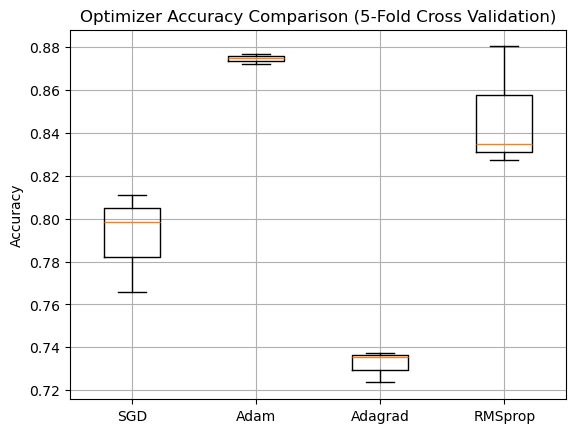

In [ ]:
# ---------------------------------------------------------------
# [옵티마이저 성능 비교 실험 - 5겹 교차 검증 기반]
# 목적:
#   동일한 MLP 구조에서 여러 옵티마이저(SGD, Adam, Adagrad, RMSprop)의 분류 성능을 비교하고,
#   5-Fold 교차 검증을 통해 모델의 일반화 성능을 통계적으로 평가함.
# 실험 배경:
#   옵티마이저는 모델 학습 속도와 정확도에 중대한 영향을 주며,
#   데이터 특성과 모델 구조에 따라 성능 차이가 발생할 수 있음.
# ---------------------------------------------------------------

import numpy as np
import tensorflow as tf
tf.config.run_functions_eagerly(True)  # 💡 텐서플로우 실행을 즉시 모드로 전환 (디버깅과 반복 훈련에 유리)

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# 1. Fashion MNIST 데이터셋 로딩
#    - 28x28 흑백 의류 이미지, 총 10개 클래스
#    - 학습 데이터: 60,000개 / 테스트 데이터: 10,000개
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. 입력 데이터 전처리
#    - 2차원 이미지를 1차원 벡터(784차원)로 변환
#    - 정수형 픽셀 값을 float32로 변환 후 0~1 범위로 정규화 (신경망 입력값 표준화)
x_train = x_train.reshape(60000, 784).astype(np.float32) / 255.0
x_test = x_test.reshape(10000, 784).astype(np.float32) / 255.0
# Fashion MNIST 이미지 데이터는 28x28 크기의 흑백 이미지로, 각 픽셀 값은 정수형 0~255 범위를 가짐 

# 3. 출력 라벨 전처리
#    - 정수 클래스(0~9)를 원-핫 벡터로 변환하여 softmax 출력과 대응시킴
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# 4. 신경망 구조 하이퍼파라미터 정의
n_input = 784     # 입력 노드 수 (28x28 이미지 벡터)
n_hidden1 = 1024  # 은닉층 1 뉴런 수
n_hidden2 = 512   # 은닉층 2 뉴런 수
n_hidden3 = 512   # 은닉층 3 뉴런 수
n_hidden4 = 512   # 은닉층 4 뉴런 수
n_output = 10     # 출력 노드 수 (10개 클래스)

# 5. 학습 설정 하이퍼파라미터
batch_siz = 256   # 미니배치 크기
n_epoch = 5      # 학습 반복 횟수
k = 3             # KFold 분할 수 (5겹 교차 검증)

# 6. 신경망 구조 정의 함수
#    - Sequential 모델 기반
#    - 은닉층: ReLU 활성화 함수 사용 (비선형성 확보 및 vanishing gradient 완화)
#    - 출력층: softmax 활성화 함수로 클래스별 확률 출력
def build_model():
    model = Sequential()
    model.add(Dense(units=n_hidden1, activation='relu', input_shape=(n_input,)))
    model.add(Dense(units=n_hidden2, activation='relu'))
    model.add(Dense(units=n_hidden3, activation='relu'))
    model.add(Dense(units=n_hidden4, activation='relu'))
    model.add(Dense(units=n_output, activation='softmax'))
    return model

# 7. 교차 검증 실행 함수
#    - opt_class: 옵티마이저 클래스 (SGD, Adam 등)
#    - 출력: 각 fold마다 계산된 검증 정확도 리스트
def cross_validation(opt_class):
    accuracy = []

    # KFold 객체로 학습/검증 인덱스 분할 수행
    for train_index, val_index in KFold(k).split(x_train):
        xtrain, xval = x_train[train_index], x_train[val_index]
        ytrain, yval = y_train[train_index], y_train[val_index]

        # 모델 생성 및 옵티마이저 인스턴스화
        dmlp = build_model()
        opt = opt_class()  # 💡 전달받은 클래스에서 인스턴스 생성

        # 모델 컴파일: 다중 클래스 분류에 적합한 손실 함수와 정확도 지표 사용
        dmlp.compile(loss='categorical_crossentropy',
                     optimizer=opt,
                     metrics=['accuracy'])

        # 모델 학습: 현재 fold의 훈련 데이터에 대해 학습 수행
        dmlp.fit(xtrain, ytrain,
                 batch_size=batch_siz,
                 epochs=n_epoch,
                 verbose=0)  # 훈련 로그 생략

        # 검증 데이터에 대한 정확도 평가 후 저장
        acc = dmlp.evaluate(xval, yval, verbose=0)[1]  # [0]=loss, [1]=accuracy
        accuracy.append(acc)

    return accuracy

# 8. 각 옵티마이저에 대해 5겹 교차 검증 수행
acc_sgd = cross_validation(SGD)
acc_adam = cross_validation(Adam)
acc_adagrad = cross_validation(Adagrad)
acc_rmsprop = cross_validation(RMSprop)

# 9. 평균 정확도 출력 (교차 검증의 평균 성능)
print("SGD 옵티마이저의 평균 정확도:", np.mean(acc_sgd))
print("Adam 옵티마이저의 평균 정확도:", np.mean(acc_adam))
print("Adagrad 옵티마이저의 평균 정확도:", np.mean(acc_adagrad))
print("RMSprop 옵티마이저의 평균 정확도:", np.mean(acc_rmsprop))

# 10. 시각화: 박스플롯으로 각 옵티마이저의 정확도 분포 비교
#     - 박스플롯: 평균, 분산, IQR, 이상치 등 통계적 분포 한눈에 파악 가능
plt.boxplot([acc_sgd, acc_adam, acc_adagrad, acc_rmsprop],
            labels=["SGD", "Adam", "Adagrad", "RMSprop"])
plt.title("Optimizer Accuracy Comparison (5-Fold Cross Validation)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()


In [ ]:
# ---------------------------------------------------------------
# [다양한 옵티마이저의 성능 비교: 5-Fold 교차 검증 + 커스텀 학습 루프]
# 
# 실험 목적:
#   - 동일한 MLP 구조에서 옵티마이저에 따른 성능 차이를 비교
#   - 5겹 교차 검증으로 각 옵티마이저의 일반화 성능 및 안정성 평가
#   - 에폭 및 미니배치 단위 로깅으로 학습 과정 실시간 추적
# 
# 비교 대상 옵티마이저:
#   - SGD, Adam, Adagrad, RMSprop (legacy 모듈 사용)
# ---------------------------------------------------------------

import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam, Adagrad, RMSprop
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. 데이터 로딩 및 전처리
# ---------------------------------------------------------------

# Fashion MNIST 데이터셋 불러오기
# - 학습 데이터: 60,000개, 테스트 데이터: 10,000개
(x_train, y_train), _ = fashion_mnist.load_data()

# 입력 데이터를 1차원 벡터(784)로 변환 후, 0~1 범위로 정규화
x_train = x_train.reshape(-1, 784).astype(np.float32) / 255.0

# 라벨을 원-핫 인코딩 형식으로 변환 (예: 3 → [0,0,0,1,0,...])
y_train = tf.keras.utils.to_categorical(y_train, 10)

# ---------------------------------------------------------------
# 2. 신경망 구조 정의 함수
# ---------------------------------------------------------------

def build_model():
    # 순차적 신경망 구성
    return Sequential([
        Dense(1024, activation='relu', input_shape=(784,)),  # 입력층 + 은닉층1
        Dense(512, activation='relu'),                       # 은닉층2
        Dense(512, activation='relu'),                       # 은닉층3
        Dense(512, activation='relu'),                       # 은닉층4
        Dense(10, activation='softmax')                      # 출력층 (10클래스)
    ])

# ---------------------------------------------------------------
# 3. 하이퍼파라미터 설정
# ---------------------------------------------------------------

batch_size = 128   # 미니배치 크기
n_epoch = 3        # 학습 반복 횟수 (에폭 수)
k = 3              # 교차 검증 fold 수

# ---------------------------------------------------------------
# 4. 교차 검증 함수 (에폭 + 배치 단위 로깅 포함)
# ---------------------------------------------------------------

def cross_validation(opt_class):
    accuracy = []  # 각 fold별 검증 정확도 저장 리스트
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)  # 데이터를 무작위로 5등분

    # K개의 Fold에 대해 반복 수행
    for fold, (train_index, val_index) in enumerate(kfold.split(x_train), 1):
        print(f"\n===== [Fold {fold}/{k}] 시작 =====")

        # 현재 fold의 훈련/검증 데이터 추출
        xtrain, xval = x_train[train_index], x_train[val_index]
        ytrain, yval = y_train[train_index], y_train[val_index]

        # 모델 생성 및 옵티마이저 설정
        model = build_model()
        optimizer = opt_class()  # 전달받은 옵티마이저 클래스 인스턴스화

        # 모델 컴파일 (손실 함수는 다중 클래스 분류용 cross entropy)
        model.compile(loss='categorical_crossentropy',
                      optimizer=optimizer,
                      metrics=['accuracy'])

        # 배치 학습을 위한 반복 횟수 계산
        steps_per_epoch = int(np.ceil(len(xtrain) / batch_size))

        # -------------------------------
        # 에폭 단위 학습 루프 시작
        # -------------------------------
        for epoch in range(1, n_epoch + 1):
            print(f"\n[Epoch {epoch}/{n_epoch}]")

            # ---------------------------
            # 배치 단위 학습 루프 시작
            # ---------------------------
            for step in range(steps_per_epoch):
                start = step * batch_size
                end = start + batch_size

                # 현재 배치 데이터 추출
                x_batch = xtrain[start:end]
                y_batch = ytrain[start:end]

                # 배치 학습 수행 (즉시 실행)
                loss, acc = model.train_on_batch(x_batch, y_batch)

                # 배치별 학습 상태 출력
                print(f"  ➤ Batch {step + 1}/{steps_per_epoch} | Loss: {loss:.4f} | Accuracy: {acc:.4f}")

            # ---------------------------
            # 에폭 종료 후 검증 평가
            # ---------------------------
            val_loss, val_acc = model.evaluate(xval, yval, verbose=0)
            print(f"✅ Epoch {epoch} Validation Accuracy: {val_acc:.4f}")

        # 마지막 에폭의 검증 정확도 저장
        accuracy.append(val_acc)

    return accuracy

# ---------------------------------------------------------------
# 5. 옵티마이저별 교차 검증 실행
# ---------------------------------------------------------------

# 각 옵티마이저에 대해 교차 검증 정확도 리스트 얻기
acc_sgd = cross_validation(SGD)
acc_adam = cross_validation(Adam)
acc_adagrad = cross_validation(Adagrad)
acc_rmsprop = cross_validation(RMSprop)

# ---------------------------------------------------------------
# 6. 평균 정확도 출력
# ---------------------------------------------------------------

print("\n===== [5-Fold 교차 검증 평균 정확도] =====")
print("SGD     :", np.mean(acc_sgd))
print("Adam    :", np.mean(acc_adam))
print("Adagrad :", np.mean(acc_adagrad))
print("RMSprop :", np.mean(acc_rmsprop))

# ---------------------------------------------------------------
# 7. 결과 시각화 (박스플롯)
# ---------------------------------------------------------------

# 각 옵티마이저의 fold별 정확도 분포를 시각화
plt.boxplot([acc_sgd, acc_adam, acc_adagrad, acc_rmsprop],
            labels=["SGD", "Adam", "Adagrad", "RMSprop"])
plt.title("Optimizer Accuracy Comparison (5-Fold Cross Validation)")
plt.ylabel("Validation Accuracy")
plt.grid()
plt.show()



===== [Fold 1/3] 시작 =====

[Epoch 1/3]
  ➤ Batch 1/313 | Loss: 2.2857 | Accuracy: 0.0938
  ➤ Batch 2/313 | Loss: 2.2879 | Accuracy: 0.0977
  ➤ Batch 3/313 | Loss: 2.2822 | Accuracy: 0.0964
  ➤ Batch 4/313 | Loss: 2.2766 | Accuracy: 0.0938
  ➤ Batch 5/313 | Loss: 2.2752 | Accuracy: 0.0938
  ➤ Batch 6/313 | Loss: 2.2701 | Accuracy: 0.0951
  ➤ Batch 7/313 | Loss: 2.2656 | Accuracy: 0.0960
  ➤ Batch 8/313 | Loss: 2.2626 | Accuracy: 0.0967
  ➤ Batch 9/313 | Loss: 2.2565 | Accuracy: 0.1085
  ➤ Batch 10/313 | Loss: 2.2533 | Accuracy: 0.1219
  ➤ Batch 11/313 | Loss: 2.2481 | Accuracy: 0.1392
  ➤ Batch 12/313 | Loss: 2.2435 | Accuracy: 0.1562
  ➤ Batch 13/313 | Loss: 2.2399 | Accuracy: 0.1683
  ➤ Batch 14/313 | Loss: 2.2353 | Accuracy: 0.1786
  ➤ Batch 15/313 | Loss: 2.2314 | Accuracy: 0.1885
  ➤ Batch 16/313 | Loss: 2.2267 | Accuracy: 0.2012
  ➤ Batch 17/313 | Loss: 2.2232 | Accuracy: 0.2100
  ➤ Batch 18/313 | Loss: 2.2188 | Accuracy: 0.2214
  ➤ Batch 19/313 | Loss: 2.2148 | Accuracy: 0.2303
